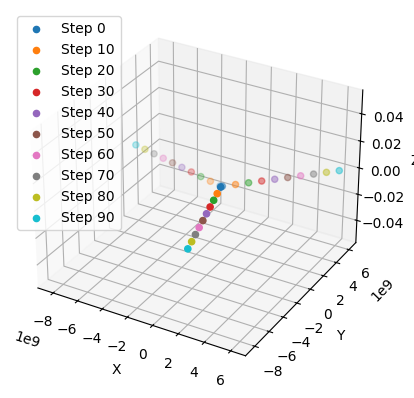

In [3]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def read_csv(filename):
    steps = []
    bodies = []
    positions = []

    with open(filename, newline='') as csvfile:
        reader = csv.reader(csvfile, delimiter=';')
        next(reader)  # Skip the header row
        for row in reader:
            step = int(row[0])
            body_id = int(row[1])
            x = float(row[2])
            y = float(row[3])
            z = float(row[4])
            
            if step not in steps:
                steps.append(step)
                bodies.append([])

            bodies[-1].append((body_id, x, y, z))

    return steps, bodies

def plot_bodies(steps, bodies, plot_interval=1):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    for idx in range(0, len(steps), plot_interval):
        step = steps[idx]
        body_positions = bodies[idx]
        xs = [pos[1] for pos in body_positions]
        ys = [pos[2] for pos in body_positions]
        zs = [pos[3] for pos in body_positions]
        ax.scatter(xs, ys, zs, label=f'Step {step}')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()

    plt.show()

def main():
    filename = 'nbody_double.txt'  # or 'nbody_float.txt'
    plot_interval = 10  # Set the interval for plotting
    steps, bodies = read_csv(filename)
    plot_bodies(steps, bodies, plot_interval)

if __name__ == '__main__':
    main()